In [2]:
import open_clip
from PIL import Image
import torch
import numpy as np
import os
import matplotlib.pyplot as plt

/opt/anaconda3/envs/neuroshock/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# --- Конфигурация ---
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

#directory = '/Users/user/Desktop/НИР2/Рентген_305'
directory = '/Users/user/Desktop/ВКР_ИТМО/АНОМАЛИИ_ДАТАСЕТ/Кожа_тест/Все'
#directory = '/Users/user/Desktop/НИР2/Коты_998'

description='leather'

glob = {'image_paths': []}

# --- Функции ---
def extract_image_info(directory):
    image_paths = [
        os.path.join(directory, f) 
        for f in os.listdir(directory) 
        if os.path.isfile(os.path.join(directory, f)) and f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    return image_paths

def extract_features(image_path):
    global description
    image = preprocess(Image.open(image_path)).unsqueeze(0)

    # Кодируем текст и изображение
    with torch.no_grad():
        #text_tokens = tokenizer(['bottle, beer, sitting, pile, table']) 
        text_tokens = tokenizer([description]) 
        text_features = model.encode_text(text_tokens)
        image_features = model.encode_image(image)
        
        similarity = torch.cosine_similarity(image_features, text_features, dim=1)
    
    return similarity.item()


def process_images(img_paths):
    vectors = []
    total = len(img_paths)
    for index, path in enumerate(img_paths):
        vectors.append(extract_features(path))
    
    if (index + 1) % 1 == 0:
        progress_msg = f"\rОбработано {index + 1}/{total} изображений"
        print(progress_msg, end='', flush=True)

    print()  # перенос строки после прогресса
    return vectors


# --- Основная логика ---
glob['image_paths'] = extract_image_info(directory)
result_vectors = np.array(process_images(glob['image_paths']))


Обработано 250/250 изображений


In [10]:
top_smallest_indices = np.argsort(result_vectors)[:10]

№_1   Аномалия_порез.png


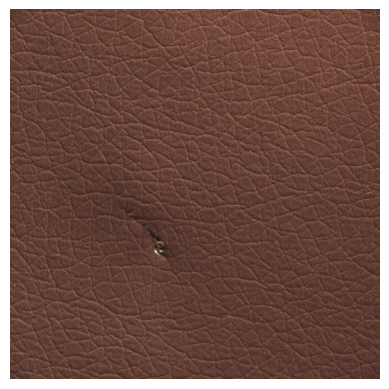

№_2   173.png


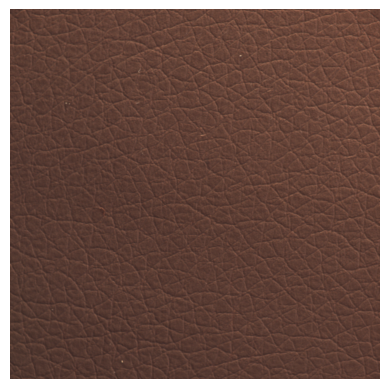

№_3   128.png


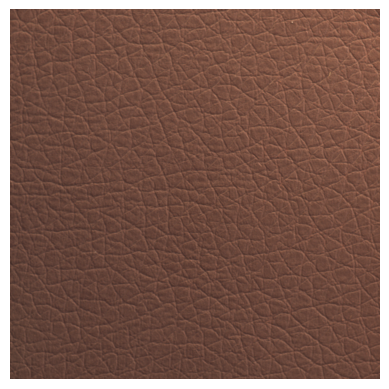

№_4   147.png


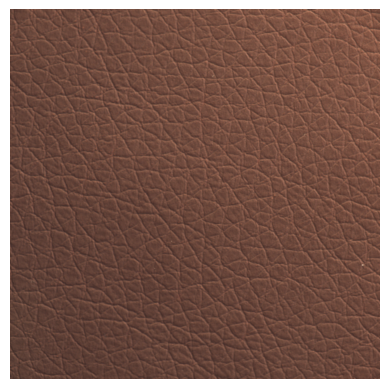

№_5   148.png


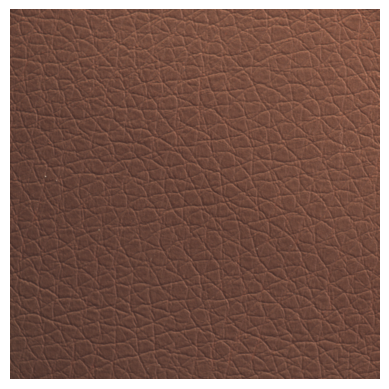

№_6   Аномалия_капля.png


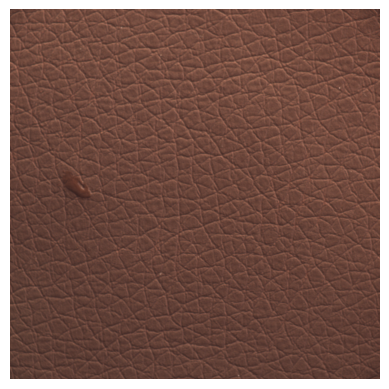

№_7   221.png


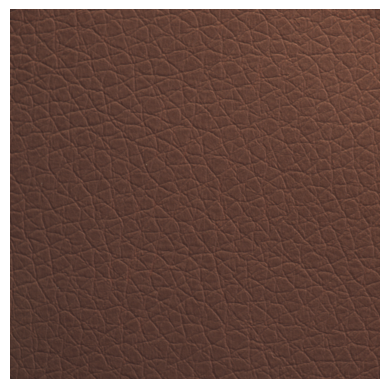

№_8   004.png


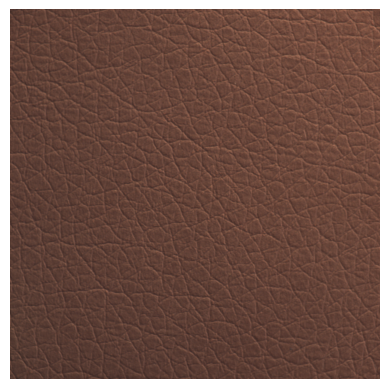

№_9   075.png


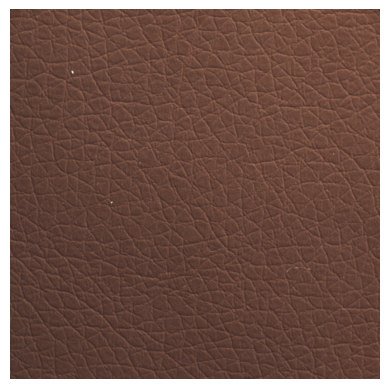

№_10   037.png


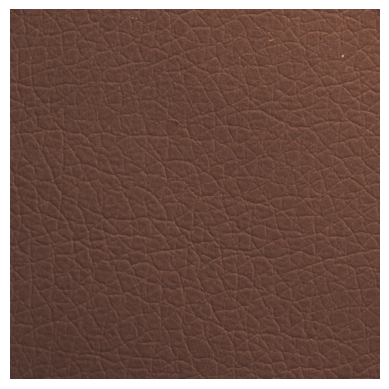

In [11]:
# выведение топа самых вероятно аномальных изображений
for i in range(len(top_smallest_indices)):
    file_path=glob['image_paths'][top_smallest_indices[i]]
    # if 'Неправильный_тип' in glob['image_paths'][top_smallest_indices[i]].split('/')[-1]:


    print(str('№')+'_'+str(i+1),' ' ,glob['image_paths'][top_smallest_indices[i]].split('/')[-1])

    img = Image.open(file_path).convert("RGB")

    plt.imshow(img)
    plt.axis('off') 
    plt.show()